In [2]:
import time
import matplotlib.pyplot as plt
from memory_profiler import memory_usage
%load_ext memory_profiler

Optimized Crew Assignment (B&B): {'C1': ['F1', 'F3'], 'C2': ['F2', 'F4'], 'C3': ['F5']}


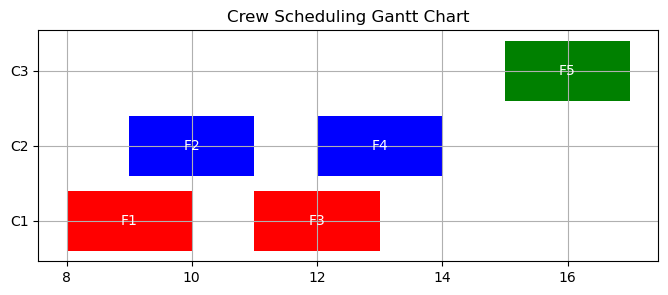

In [4]:
# --- TASK 1 & 2: BACKTRACKING AND BRANCH & BOUND ---
flights = [('F1', 8, 10), ('F2', 9, 11), ('F3', 11, 13), ('F4', 12, 14), ('F5', 15, 17)]
crew_members = ['C1', 'C2', 'C3']
REST_TIME = 1

def is_valid(assignment, flight, crew, flights_dict):
    start, end = flights_dict[flight]
    for assigned_f in assignment.get(crew, []):
        a_start, a_end = flights_dict[assigned_f]
        # Constraint: Ensure no overlap and sufficient rest time
        if not (end + REST_TIME <= a_start or start >= a_end + REST_TIME):
            return False
    return True

best_assignment = None
min_max_load = float('inf') # Branch & Bound constraint

def solve_scheduling(f_idx, current_assignment, flights_list, flights_dict):
    global best_assignment, min_max_load
    
    # Base Case: All flights assigned
    if f_idx == len(flights_list):
        max_load = max(len(v) for v in current_assignment.values()) if current_assignment else 0
        if max_load < min_max_load:
            min_max_load = max_load
            best_assignment = {k: list(v) for k, v in current_assignment.items()}
        return

    flight = flights_list[f_idx][0]
    
    # TASK 2 (Branch & Bound Pruning): Stop exploring if current max load >= best found so far
    current_max = max([len(v) for v in current_assignment.values()] + [0])
    if current_max >= min_max_load:
        return 

    # TASK 1 (Backtracking Algorithm)
    for crew in crew_members:
        if is_valid(current_assignment, flight, crew, flights_dict):
            current_assignment.setdefault(crew, []).append(flight) # Choose
            solve_scheduling(f_idx + 1, current_assignment, flights_list, flights_dict) # Explore
            current_assignment[crew].pop() # Backtrack

flights_dict = {f[0]: (f[1], f[2]) for f in flights}
solve_scheduling(0, {c: [] for c in crew_members}, flights, flights_dict)
print("Optimized Crew Assignment (B&B):", best_assignment)

# OPTIONAL VIZ: Gantt Chart
fig, ax = plt.subplots(figsize=(8, 3))
colors = {'C1': 'red', 'C2': 'blue', 'C3': 'green'}
for i, (crew, assigned_flights) in enumerate(best_assignment.items()):
    for f in assigned_flights:
        start, end = flights_dict[f]
        ax.broken_barh([(start, end-start)], (i - 0.4, 0.8), facecolors=colors[crew])
        ax.text(start + (end-start)/2, i, f, color='white', ha='center', va='center')
ax.set_yticks(range(len(crew_members)))
ax.set_yticklabels(best_assignment.keys())
ax.set_title('Crew Scheduling Gantt Chart')
plt.grid(True)
plt.show()

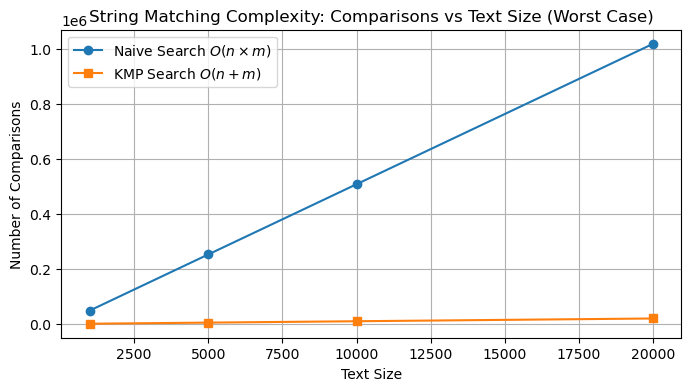

In [6]:
# --- TASK 3 & 4: STRING MATCHING ALGORITHMS & PROFILING ---

def naive_search(text, pattern):
    n, m = len(text), len(pattern)
    comparisons = 0
    matches = []
    for i in range(n - m + 1):
        match = True
        for j in range(m):
            comparisons += 1
            if text[i+j] != pattern[j]:
                match = False
                break
        if match: matches.append(i)
    return matches, comparisons

def compute_lps(pattern):
    m = len(pattern)
    lps = [0] * m
    length, i = 0, 1
    while i < m:
        if pattern[i] == pattern[length]:
            length += 1; lps[i] = length; i += 1
        else:
            if length != 0: length = lps[length - 1]
            else: lps[i] = 0; i += 1
    return lps

def kmp_search(text, pattern):
    n, m = len(text), len(pattern)
    lps = compute_lps(pattern)
    i = j = comparisons = 0
    matches = []
    while i < n:
        comparisons += 1
        if pattern[j] == text[i]: i += 1; j += 1
        if j == m:
            matches.append(i - j)
            j = lps[j - 1]
        elif i < n and pattern[j] != text[i]:
            if j != 0: j = lps[j - 1]
            else: i += 1
    return matches, comparisons

# Task 4: Compare Performance
text_sizes = [1000, 5000, 10000, 20000]
naive_comps, kmp_comps = [], []

# Creating a worst-case scenario string (e.g., AAAAAB searched for AAB)
for size in text_sizes:
    test_text = "A" * size + "B"
    test_pattern = "A" * 50 + "B"
    _, nc = naive_search(test_text, test_pattern)
    _, kc = kmp_search(test_text, test_pattern)
    naive_comps.append(nc)
    kmp_comps.append(kc)

plt.figure(figsize=(8,4))
plt.plot(text_sizes, naive_comps, label='Naive Search $O(n \\times m)$', marker='o')
plt.plot(text_sizes, kmp_comps, label='KMP Search $O(n + m)$', marker='s')
plt.title('String Matching Complexity: Comparisons vs Text Size (Worst Case)')
plt.xlabel('Text Size')
plt.ylabel('Number of Comparisons')
plt.legend()
plt.grid(True)
plt.show()

## 4.6 Reflection & Discussion

* **Complexity Awareness:** Backtracking fails to scale beyond ~10 flights because it explores combinations factorially/exponentially ($O(N!)$ or $O(C^F)$). Even with pruning, the search tree becomes too massive for standard compute times.
* **Constraint Handling:** Overlap is simpler as it just checks boundary variables. Enforcing *rest time* is slightly harder because it requires tracking states across multiple assignments and verifying buffer gaps ($end + REST \le start$).
* **Heuristics & Optimization:** AI techniques like **Genetic Algorithms** or **Simulated Annealing** could drastically reduce the search space. Instead of searching exhaustively, they start with a random valid schedule and mutate it to find "good enough" local optima quickly.
* **Visualization Usefulness:** The Gantt chart instantly validated the algorithm by visually proving that no two blocks of the same color overlap and that there are clear graphical spaces representing the 1-hour rest times.
* **Extendability:** Real-world models need data fields like `crew_max_weekly_hours`, `flight_departure_location` (you can't assign a crew in NY to a flight leaving LA in 2 hours), and `delay_probabilities`.